In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

# This block is optional for local runs.
# It tries to download the dataset via kagglehub if available.
try:
    import kagglehub  # pip install kagglehub
    techsash_waste_classification_data_path = kagglehub.dataset_download('techsash/waste-classification-data')
    print('Data source import complete.')
except Exception as e:
    print('Skipping Kaggle download (not available locally):', e)
    techsash_waste_classification_data_path = None

Skipping Kaggle download (not available locally): No module named 'kagglehub'


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import os

base_path = techsash_waste_classification_data_path

# Try to autodetect a local dataset if Kaggle download isn't available
if base_path is None:
    candidates = [
        os.getcwd(),
        os.path.dirname(os.getcwd()),
    ]
    found = None
    for root in candidates:
        for sub in ("dataset", "DATASET", "waste-classification-data", "waste_classification", "data"):
            p = os.path.join(root, sub)
            if os.path.isdir(p):
                found = root
                break
        if found:
            break
    base_path = found

if base_path is None:
    print("Dataset not found. Please set 'base_path' to your dataset root.")
else:
    print("Base path:", base_path)
    try:
        print("Contents:", os.listdir(base_path))
    except Exception as e:
        print("Could not list base path contents:", e)


Dataset not found. Please set 'base_path' to your dataset root.


In [4]:
import os

if base_path is None:
    print("Dataset base_path is not set; proceeding without local dataset.")

candidates = []
if base_path is not None:
    candidates = [
        os.path.join(base_path, "dataset", "DATASET"),
        os.path.join(base_path, "DATASET"),
        base_path,  # in case base_path already is the DATASET folder
    ]

data_root = None
for p in candidates:
    if os.path.isdir(p) and os.path.isdir(os.path.join(p, "TRAIN")) and os.path.isdir(os.path.join(p, "TEST")):
        data_root = p
        break

if data_root is None and base_path is not None:
    # Search one level under base_path for a folder containing TRAIN and TEST
    try:
        for name in os.listdir(base_path):
            p = os.path.join(base_path, name)
            if os.path.isdir(p) and os.path.isdir(os.path.join(p, "TRAIN")) and os.path.isdir(os.path.join(p, "TEST")):
                data_root = p
                break
    except Exception:
        pass

if data_root is None:
    data_available = False
    print("Could not locate a folder with TRAIN and TEST under base_path. Skipping dataset-dependent steps.")
    train_path = None
    test_path = None
else:
    data_available = True
    train_path = os.path.join(data_root, "TRAIN")
    test_path  = os.path.join(data_root, "TEST")
    print("Resolved data_root:", data_root)


Dataset base_path is not set; proceeding without local dataset.
Could not locate a folder with TRAIN and TEST under base_path. Skipping dataset-dependent steps.


In [5]:
if data_available:
    print("Train folders:", os.listdir(train_path))
    print("Test folders:", os.listdir(test_path))
else:
    print("Dataset not available; skipping folder listing.")


Dataset not available; skipping folder listing.


In [6]:
import cv2
from tqdm import tqdm
from collections import Counter

x_data = []
y_data = []

if data_available:
    for label in os.listdir(train_path):
        label_path = os.path.join(train_path, label)
        for file in tqdm(os.listdir(label_path), desc=f"Loading {label}"):
            img_path = os.path.join(label_path, file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            x_data.append(img)
            y_data.append(label)
    data = pd.DataFrame({"image": x_data, "label": y_data})
    print("Class distribution:", Counter(y_data))
else:
    print("Dataset not available; skipping image loading.")


Dataset not available; skipping image loading.


In [7]:
from collections import Counter

if data_available and y_data:
    Counter(y_data)
else:
    print("No labels to count; dataset not available or not loaded.")


No labels to count; dataset not available or not loaded.


In [8]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
import warnings
warnings.filterwarnings("ignore")

In [9]:
# Use TensorFlow Keras consistently
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.utils import plot_model
from glob import glob
from sklearn.preprocessing import StandardScaler

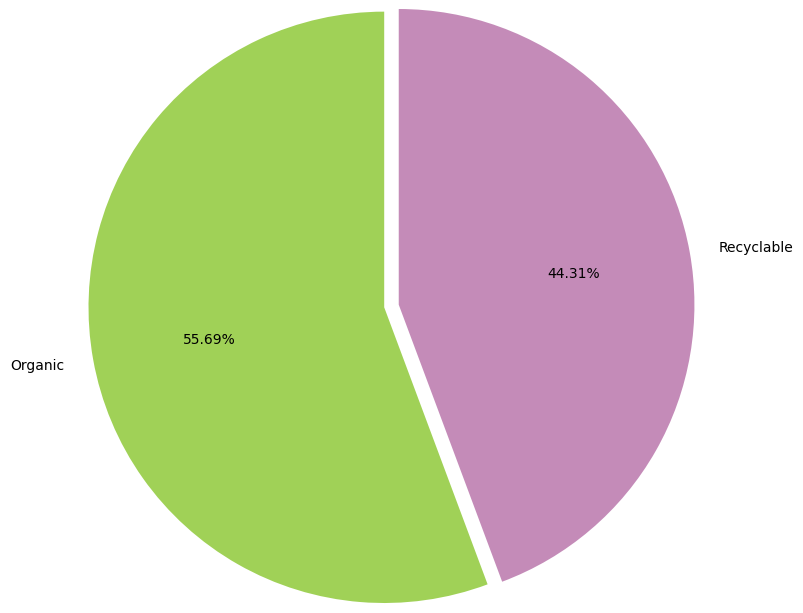

In [ ]:
if data_available:
    colors = ["#a0d157", "#c48bb8"]
    plt.pie(data.label.value_counts(), startangle=90, explode=[0.05,0.05],autopct="%0.2f%%", labels=["Organic", "Recyclable"], colors=colors, radius=2)
    plt.show()
else:
    print("Dataset not available; skipping class distribution plot.")


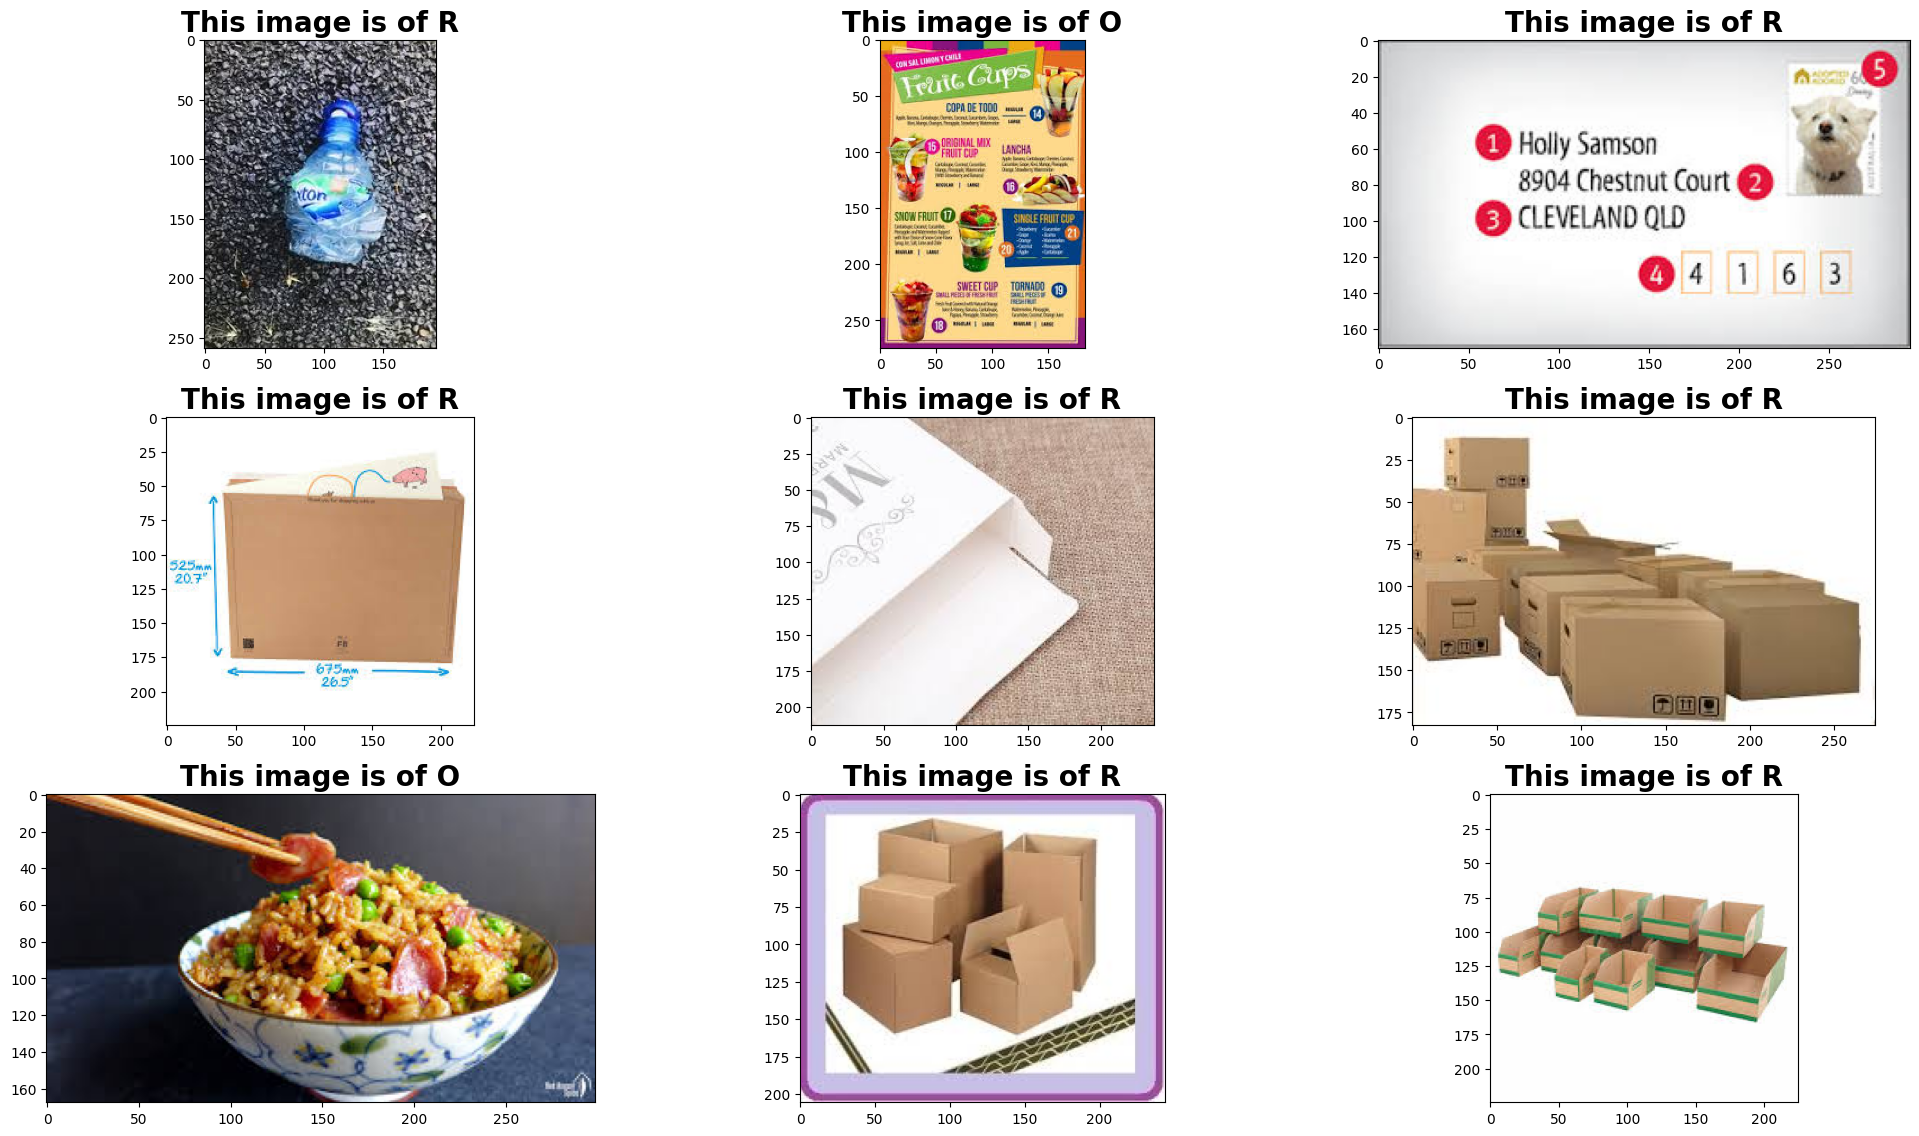

In [ ]:
if data_available:
    plt.figure(figsize=(20,15))
    for i in range(9):
        plt.subplot(4,3,(i%12)+1)
        index = np.random.randint(len(data))
        plt.title("This image is of {0}".format(data.label[index]), fontdict={"size":20, "weight":"bold"})
        plt.imshow(data.image[index])
        plt.tight_layout()
else:
    print("Dataset not available; skipping sample image grid.")


In [ ]:
if data_available:
    className = glob(train_path+"/*")
    numberOfClass = len(className)
    print("Number of Class: ", numberOfClass)
else:
    print("Dataset not available; skipping class count.")


Number of Class:  2


In [10]:
model = Sequential()
model.add(Conv2D(32,(3,3),input_shape=(224,224,3)))
model.add(Activation("relu"))
model.add(MaxPooling2D())
model.add(Conv2D(64,(3,3)))
model.add(Activation("relu"))
model.add(MaxPooling2D())
model.add(Conv2D(128,(3,3)))
model.add(Activation("relu"))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(256))
model.add(Activation("relu"))
model.add(Dropout(0.5))
model.add(Dense(64))
model.add(Activation("relu"))
model.add(Dropout(0.5))
# Two-class softmax head for categorical training
model.add(Dense(2, activation="softmax"))

In [11]:
# Compile the model with categorical setup
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

batch_size = 256

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 109, 109, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 52, 52, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,261,250 (84.92 MB)

 Trainable params: 22,261,250 (84.92 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


In [14]:
if data_available:
    train_generator = train_datagen.flow_from_directory(train_path, target_size=(224, 224), batch_size=batch_size, color_mode="rgb", class_mode="categorical")
    test_generator = test_datagen.flow_from_directory(test_path, target_size=(224, 224), batch_size=batch_size, color_mode="rgb", class_mode="categorical")
else:
    train_generator = None
    test_generator = None
    print("Dataset not available; skipping data generators.")


Dataset not available; skipping data generators.


In [15]:
if data_available and train_generator is not None and test_generator is not None:
    hist = model.fit(train_generator, epochs=10, validation_data=test_generator)
else:
    hist = None
    print("Dataset not available; skipping model training.")


Dataset not available; skipping model training.


In [16]:
if hist is not None:
    plt.figure(figsize=[10,6])
    plt.plot(hist.history["accuracy"], label = "Train acc")
    plt.plot(hist.history["val_accuracy"], label = "Validation acc")
    plt.legend()
    plt.show()
else:
    print("No training history; skipping accuracy plot.")


No training history; skipping accuracy plot.


In [17]:
if hist is not None:
    plt.figure(figsize=(10,6))
    plt.plot(hist.history['loss'], label = "Train loss")
    plt.plot(hist.history['val_loss'], label = "Validation loss")
    plt.legend()
    plt.show()
else:
    print("No training history; skipping loss plot.")


No training history; skipping loss plot.


In [18]:
def predict_func(img):
    plt.figure(figsize=(6,4))
    # ensure RGB for plotting
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.tight_layout()
    # preprocess for model
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)
    preds = model.predict(img)
    result = int(np.argmax(preds, axis=1)[0])
    if result == 0:
        print("\033[94m"+"This image -> Recyclable"+"\033[0m")
    elif result == 1:
        print("\033[94m"+"This image -> Organic"+"\033[0m")

In [19]:
if data_available and test_path is not None:
    # try an example from Organic class if exists
    candidate = os.path.join(test_path, "O")
    sample = None
    if os.path.isdir(candidate):
        for fname in os.listdir(candidate):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                sample = os.path.join(candidate, fname)
                break
    if sample and os.path.exists(sample):
        test_img = cv2.imread(sample)
        predict_func(test_img)
    else:
        print("No sample image found under:", candidate)
else:
    print("Dataset not available; skipping test prediction.")


Dataset not available; skipping test prediction.


In [20]:
if hist is not None:
    model.save("Waste Management System.h5")
    print("Model saved to Waste Management System.h5")
else:
    print("Training was skipped; not overwriting existing model file.")


Training was skipped; not overwriting existing model file.


In [21]:
# Install streamlit in notebook environment if needed
!pip install -q streamlit


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import streamlit as st
from tensorflow.keras.models import load_model
from PIL import Image
import numpy as np
import cv2
import os

# Load the pre-trained Keras model
# Ensure the model file 'Waste Management System.h5' is in the same directory or provide the full path.
model_path = os.path.join(os.getcwd(), 'Waste Management System.h5')
model = load_model(model_path)

# Define the class names for prediction output
class_names = ['Organic', 'Recyclable']

# Function to preprocess the image and make a prediction
def predict_waste_type(image_data):
    img = image_data.convert('RGB').resize((224, 224))
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)

    if predictions.ndim == 2 and predictions.shape[1] == 1:
        prob = float(predictions[0][0])
        idx = 1 if prob >= 0.5 else 0
        predicted_class = class_names[idx]
    else:
        predicted_class_index = int(np.argmax(predictions, axis=1)[0])
        predicted_class = class_names[predicted_class_index]
    return predicted_class

# Streamlit app layout
st.title("Waste Classification App")
st.write("Upload an image to classify it as Organic or Recyclable waste.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded Image', use_column_width=True)
    st.write("")

    if st.button('Classify'):
        with st.spinner('Classifying...'):
            predicted_label = predict_waste_type(image)
            st.success(f"Prediction: This waste is **{predicted_label}**")

st.markdown("--- App Developed for Waste Classification --- ")

# To run this Streamlit app:
# streamlit run app.py

2025-12-19 10:55:43.055 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-19 10:55:45.580 
  command:

    streamlit run c:\Users\ADMIN\Downloads\Waste Management System-20251218T095643Z-3-001\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-12-19 10:55:45.582 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-19 10:55:45.584 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-19 10:55:45.586 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-19 10:55:45.588 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-19 10:55:45.591 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare 

DeltaGenerator()